# WiLoR Hand Pose Estimation Demo

3D hand pose estimation using WiLoR-mini.

In [2]:
!pip install --no-build-isolation git+https://github.com/warmshao/WiLoR-mini
!pip install opencv-python

import cv2
import numpy as np
import torch
from wilor_mini.pipelines.wilor_hand_pose3d_estimation_pipeline import WiLorHandPose3dEstimationPipeline

# Landmark indices
WRIST = 0
THUMB_TIP = 4
INDEX_TIP = 8

  Cloning https://github.com/warmshao/WiLoR-mini to /tmp/pip-req-build-t9kiw9fd
  Running command git clone --filter=blob:none --quiet https://github.com/warmshao/WiLoR-mini /tmp/pip-req-build-t9kiw9fd
  Resolved https://github.com/warmshao/WiLoR-mini to commit ebec42f94c389070cdd7dda6fd1bf0b4a659c960
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/mattloper/chumpy to /tmp/pip-install-9z27upwz/chumpy_4a6662310cd74fc3bbd2d7714f87cd91
  Running command git clone --filter=blob:none --quiet https://github.com/mattloper/chumpy /tmp/pip-install-9z27upwz/chumpy_4a6662310cd74fc3bbd2d7714f87cd91
  Resolved https://github.com/mattloper/chumpy to commit 580566eafc9ac68b2614b64d6f7aaa84eebb70da
  Preparing metadata (setup.py) ... done

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
def calculate_gripper_angle(joints_3d: np.ndarray) -> float:
    """Calculate angle between thumb and index finger vectors from wrist."""
    wrist = joints_3d[WRIST]
    thumb = joints_3d[THUMB_TIP]
    index = joints_3d[INDEX_TIP]

    # Vectors from wrist to fingertips
    v_thumb = thumb - wrist
    v_index = index - wrist

    # Angle between vectors
    cos_angle = np.dot(v_thumb, v_index) / (np.linalg.norm(v_thumb) * np.linalg.norm(v_index) + 1e-6)
    angle_deg = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))
    return angle_deg


def draw_hand_landmarks(image: np.ndarray, outputs: dict) -> np.ndarray:
    """Draw wrist, thumb tip, and index tip landmarks on the image."""
    img = image.copy()

    if not outputs or len(outputs) == 0:
        return img

    landmarks = [
        (WRIST, "Wrist", (0, 255, 0)),
        (THUMB_TIP, "Thumb", (255, 0, 0)),
        (INDEX_TIP, "Index", (0, 0, 255)),
    ]

    for hand_idx, hand_data in enumerate(outputs):
        wilor_preds = hand_data.get('wilor_preds', {})
        if 'pred_keypoints_2d' not in wilor_preds or 'pred_keypoints_3d' not in wilor_preds:
            continue

        joints_2d = np.squeeze(wilor_preds['pred_keypoints_2d'], axis=0)
        joints_3d = np.squeeze(wilor_preds['pred_keypoints_3d'], axis=0)

        is_right = hand_data.get('is_right', 1.0)
        hand_side = 'right' if is_right > 0.5 else 'left'

        print(f"\n{hand_side.upper()} hand:")
        for idx, name, _ in landmarks:
            x, y, z = joints_3d[idx]
            print(f"  {name:6s}: x={x:7.3f}, y={y:7.3f}, z={z:7.3f}")

        thumb_pt = tuple(map(int, joints_2d[THUMB_TIP][:2]))
        index_pt = tuple(map(int, joints_2d[INDEX_TIP][:2]))
        cv2.line(img, thumb_pt, index_pt, (255, 0, 255), 2)

        gripper_angle = calculate_gripper_angle(joints_3d)
        mid_pt = ((thumb_pt[0] + index_pt[0]) // 2, (thumb_pt[1] + index_pt[1]) // 2)
        cv2.putText(img, f"{gripper_angle:.1f} deg", (mid_pt[0] + 10, mid_pt[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        for idx, name, color in landmarks:
            pt = tuple(map(int, joints_2d[idx][:2]))
            cv2.circle(img, pt, 8, color, -1)
            cv2.circle(img, pt, 8, (0, 0, 0), 2)
            cv2.putText(img, name, (pt[0] + 10, pt[1] - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return img

## Initialize Pipeline

In [6]:
print("Initializing WiLoR pipeline...")

# Force CPU to avoid CUDA compatibility issues
# Set USE_GPU = True to attempt GPU acceleration
USE_GPU = True

if USE_GPU and torch.cuda.is_available():
    device = torch.device("cuda")
    dtype = torch.float16
else:
    device = torch.device("cpu")
    dtype = torch.float32

print(f"Using device: {device}, dtype: {dtype}")

pipe = WiLorHandPose3dEstimationPipeline(device=device, dtype=dtype)
print("Pipeline ready!")

[20260113 06:48:04] [INFO] WiLorHandPose3dEstimationPipeline | wilor_hand_pose3d_estimation_pipeline | loading WiLor model >>> 


Initializing WiLoR pipeline...
Using device: cuda, dtype: torch.float16


[20260113 06:48:12] [INFO] WiLorHandPose3dEstimationPipeline | wilor_hand_pose3d_estimation_pipeline | loading Yolo hand detection model >>> 


Pipeline ready!


## Run on Image

[20260113 06:48:18] [INFO] WiLorHandPose3dEstimationPipeline | wilor_hand_pose3d_estimation_pipeline | start hand detection >>> 



0: 352x512 1 right, 80.6ms
Speed: 6.0ms preprocess, 80.6ms inference, 59.8ms postprocess per image at shape (1, 3, 352, 512)


[20260113 06:48:18] [INFO] WiLorHandPose3dEstimationPipeline | wilor_hand_pose3d_estimation_pipeline | detect 1 hands
[20260113 06:48:18] [INFO] WiLorHandPose3dEstimationPipeline | wilor_hand_pose3d_estimation_pipeline | start hand 3d pose estimation >>> 
100%|██████████| 1/1 [00:07<00:00,  7.55s/it]
[20260113 06:48:26] [INFO] WiLorHandPose3dEstimationPipeline | wilor_hand_pose3d_estimation_pipeline | finish detection!


Detected 1 hand(s)

RIGHT hand:
  Wrist : x=  0.096, y=  0.006, z=  0.006
  Thumb : x=  0.195, y= -0.067, z= -0.039
  Index : x=  0.097, y= -0.113, z= -0.108


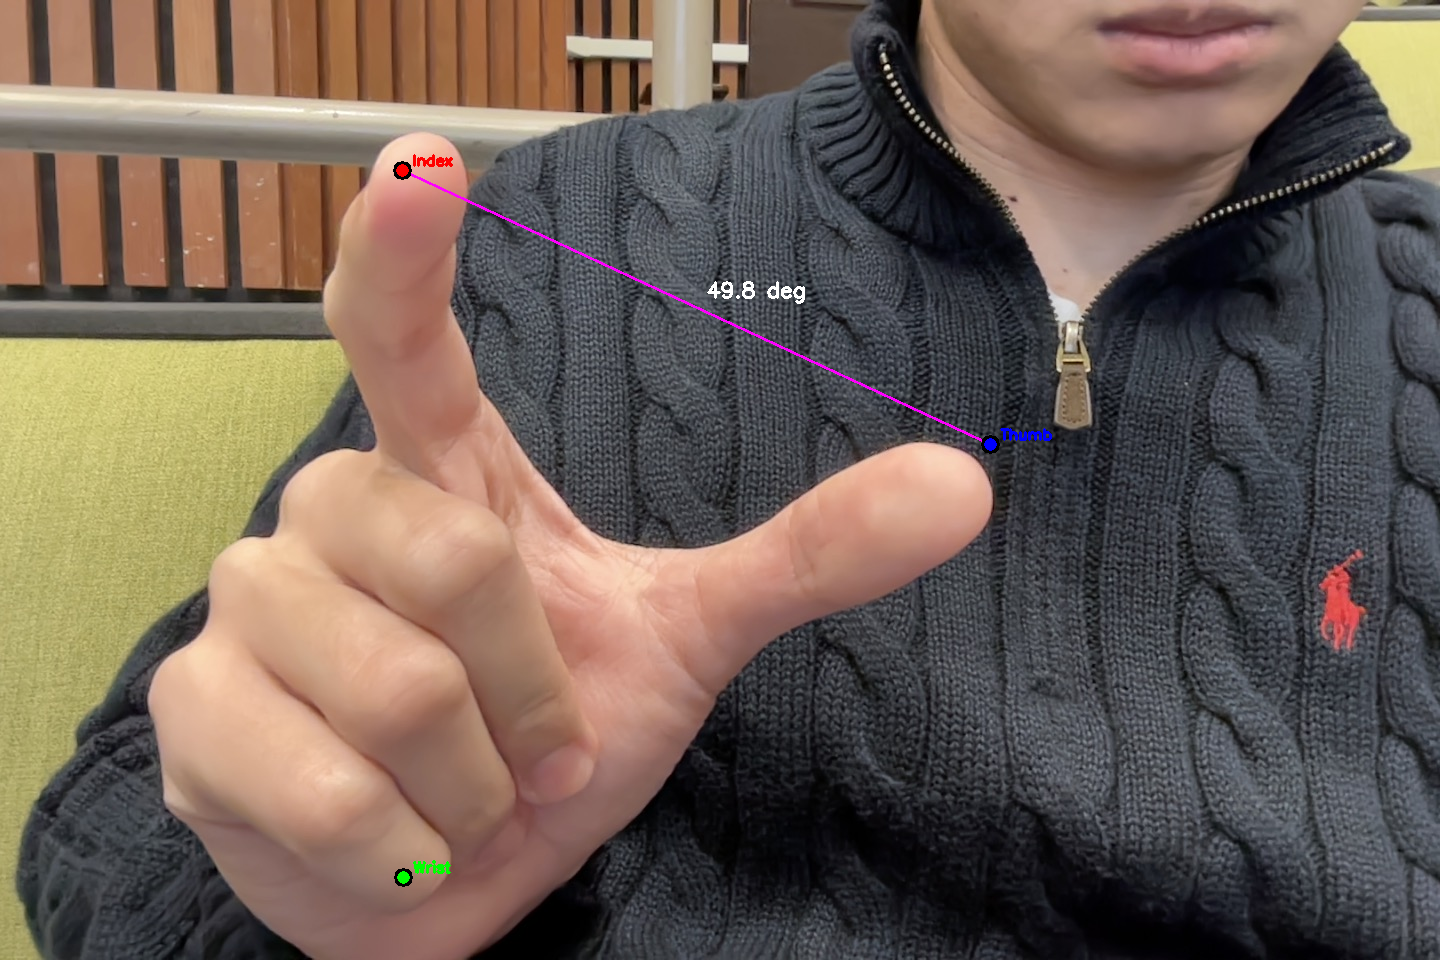

In [7]:
# Set your image path here
IMAGE_PATH = "img/image.jpg"

image = cv2.imread(IMAGE_PATH)
if image is None:
    print(f"Error: Could not load image from {IMAGE_PATH}")
else:
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    outputs = pipe.predict(rgb_image)
    print(f"Detected {len(outputs) if outputs else 0} hand(s)")
    
    result_image = draw_hand_landmarks(image, outputs)
    result_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)
    
    # Display in notebook
    from IPython.display import display
    from PIL import Image
    display(Image.fromarray(result_rgb))

## Run on Video File

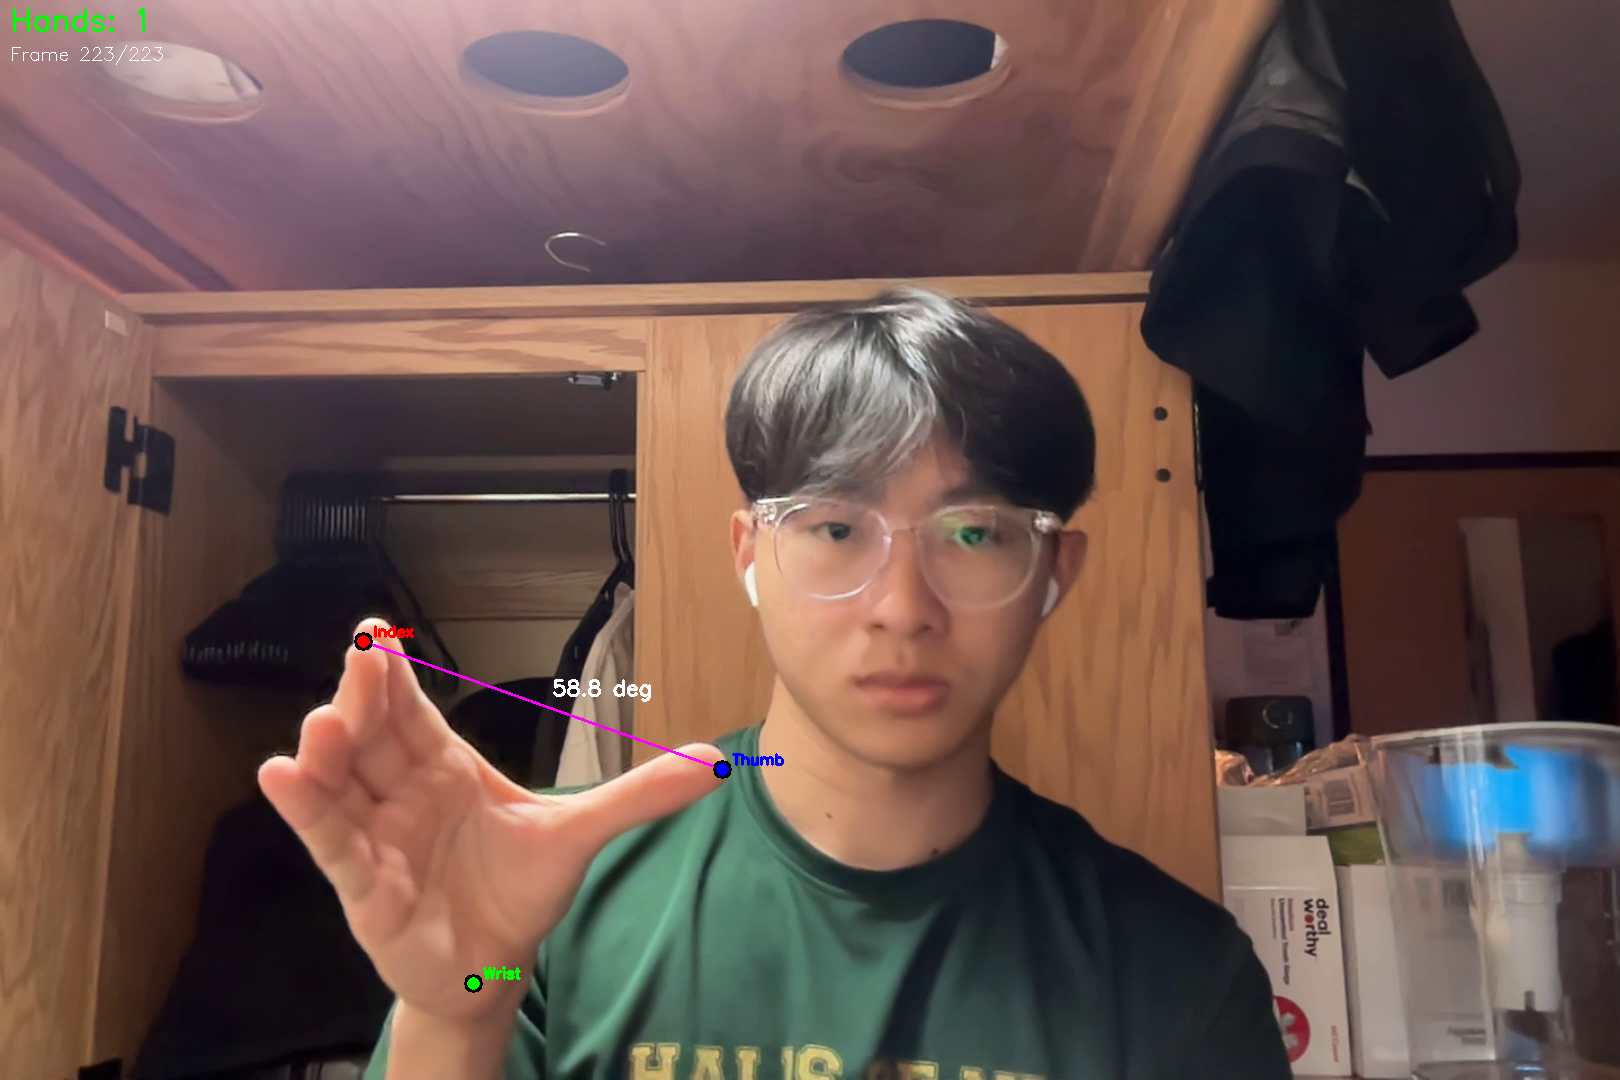


Video finished.


In [12]:
# Set your video path here
VIDEO_PATH = "video/video1.mov"

from IPython.display import display, clear_output
from PIL import Image
import time

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    print(f"Error: Could not open video: {VIDEO_PATH}")
else:
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    print(f"Video: {VIDEO_PATH}")
    print(f"Frames: {total_frames}, FPS: {fps:.1f}")
    print("Processing... (interrupt kernel to stop)")

    frame_num = 0

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("\nVideo finished.")
                break
            frame_num += 1

            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            outputs = pipe.predict(rgb_frame)
            result_frame = draw_hand_landmarks(frame, outputs)

            num_hands = len(outputs) if outputs else 0
            cv2.putText(result_frame, f"Hands: {num_hands}", (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(result_frame, f"Frame {frame_num}/{total_frames}", (10, 60),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

            # Display inline (clear previous frame)
            result_rgb = cv2.cvtColor(result_frame, cv2.COLOR_BGR2RGB)
            clear_output(wait=True)
            display(Image.fromarray(result_rgb))

    except KeyboardInterrupt:
        print("\nStopped by user.")
    finally:
        cap.release()

## Run on Live Camera

In [ ]:
# Set camera index (0 = default camera)
CAMERA_INDEX = 0

cap = cv2.VideoCapture(CAMERA_INDEX)
if not cap.isOpened():
    print(f"Error: Could not open webcam {CAMERA_INDEX}")
else:
    print(f"Live feed running (camera {CAMERA_INDEX}). Press 'q' to quit.")
    print("Show your hands to the camera!")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        outputs = pipe.predict(rgb_frame)
        result_frame = draw_hand_landmarks(frame, outputs)

        num_hands = len(outputs) if outputs else 0
        cv2.putText(result_frame, f"Hands detected: {num_hands}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.putText(result_frame, "Press 'q' to quit", (10, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        cv2.imshow("WiLoR Demo", result_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

Live Feed

In [11]:
# Set camera index (0 = default camera)
CAMERA_INDEX = 1

cap = cv2.VideoCapture(CAMERA_INDEX)
if not cap.isOpened():
    print(f"Error: Could not open webcam {CAMERA_INDEX}")
else:
    print(f"Live feed running (camera {CAMERA_INDEX}). Press 'q' to quit.")
    print("Show your hands to the camera!")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        outputs = pipe.predict(rgb_frame)
        result_frame = draw_hand_landmarks(frame, outputs)

        num_hands = len(outputs) if outputs else 0
        cv2.putText(result_frame, f"Hands detected: {num_hands}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.putText(result_frame, "Press 'q' to quit", (10, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        cv2.imshow("WiLoR Demo", result_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

Error: Could not open webcam 1


[ WARN:0@688.815] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video1): can't open camera by index
[ERROR:0@688.815] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
